# 03. Exploratory Data Analysis

변수별 분포와 변수 간 관계를 탐색합니다.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit


# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

# 데이터 불러오기
df = pd.read_csv('../merged_data.csv')

# 제어전략(Strategy) 파생변수 생성 - Batch_ID 기준 매핑
def get_strategy(bid):
    if bid <= 30: return 'RC'
    elif bid <= 60: return 'OC'
    elif bid <= 90: return 'APC'
    else: return 'Fault'
df['Strategy'] = df['Batch_ID'].apply(get_strategy)

# 컬럼 그룹 정의 (X값 후보만)
core_cols = ['Penicillin concentration(P:g/L)', 'Substrate concentration(S:g/L)',
             'Dissolved oxygen concentration(DO2:mg/L)', 'Vessel Volume(V:L)',
             'pH(pH:pH)', 'Temperature(T:K)']

operating_cols = ['Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Aeration rate(Fg:L/h)',
                  'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)',
                  'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)',
                  'Water for injection/dilution(Fw:L/h)', 'PAA flow(Fpaa:PAA flow (L/h))',
                  'Oil flow(Foil:L/hr)', 'Air head pressure(pressure:bar)',
                  'Generated heat(Q:kJ)', 'Vessel Weight(Wt:Kg)', 'Dumped broth flow(Fremoved:L/h)',
                  'Ammonia shots(NH3_shots:kgs)', 'carbon dioxide percent in off-gas(CO2outgas:%)',
                  'Oxygen in percent in off-gas(O2:O2  (%))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))',
                  'Carbon evolution rate(CER:g/h)']

offline_cols = ['Offline Biomass concentratio(X_offline:X(g L^{-1}))',
                'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
                'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
                'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
                'Viscosity(Viscosity_offline:centPoise)']

y_cols = ['Penicllin_yield_total (kg)', 'Penicllin_harvested_end_of_batch (kg)',
          'Penicllin_harvested_during_batch(kg)']

# 컬럼명
batch_col = 'Batch_ID'
time_col = 'Time (h)'

total_col = 'Penicllin_yield_total (kg)'
during_col = 'Penicllin_harvested_during_batch(kg)'
end_col = 'Penicllin_harvested_end_of_batch (kg)'

p_col = 'Penicillin concentration(P:g/L)'
volume_col = 'Vessel Volume(V:L)'

# 시간순 정렬
df = df.sort_values([batch_col, time_col]).copy()

# 1. Train/Test 배치 단위 분할 확인

In [13]:
# 같은 배치의 시계열이 Train과 Test에 섞이지 않도록
# Batch_ID를 그룹으로 지정해 분할
gss = GroupShuffleSplit(
    n_splits=1,       # 한 번 분할
    test_size=0.2,    # 전체 배치 중 20%를 Test로 사용
    random_state=42   # 팀 전체가 같은 분할을 재현하도록 고정
)

# groups에 Batch_ID를 넣어 배치 단위로 분할
train_idx, test_idx = next(
    gss.split(df, groups=df[batch_col])
)

# 분할된 행으로 Train/Test 데이터 생성
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Train/Test에 들어간 고유 배치번호 확인
train_batches = sorted(train_df[batch_col].unique())
test_batches = sorted(test_df[batch_col].unique())

print('Train 배치 수:', len(train_batches))
print('Test 배치 수:', len(test_batches))

print('\nTrain 전략별 배치 수')
print(
    train_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\nTest 전략별 배치 수')
print(
    test_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

# 같은 배치가 양쪽에 동시에 들어갔는지 확인
overlap = set(train_batches) & set(test_batches)

print('\nTrain/Test 중복 배치:', sorted(overlap))

if len(overlap) == 0:
    print('Train과 Test에 중복된 배치가 없습니다.')
else:
    print('Train과 Test에 같은 배치가 포함되어 있습니다.')

Train 배치 수: 80
Test 배치 수: 20

Train 전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: Batch_ID, dtype: int64

Test 전략별 배치 수
Strategy
RC       6
OC       7
APC      6
Fault    1
Name: Batch_ID, dtype: int64

Train/Test 중복 배치: []
Train과 Test에 중복된 배치가 없습니다.


### 1. 결과 해석

- 전체 100개 배치가 Train 80개, Test 20개로 정상 분리됐다.
- Train과 Test에 중복 배치가 없으므로 같은 배치의 유사한 시계열 값이 양쪽에 섞이는 데이터 누수를 방지했다.
- 이후 골든배치 후보와 상·하위 20% 기준은 Train 80개 배치만 사용해 선정해야 한다.
- Test의 Fault 배치는 1개뿐이므로, 향후 Test 결과만으로 Fault 그룹의 성능을 일반화하지 않는다.
- random_state=42를 사용했기 때문에 팀원들도 같은 Train/Test 구성을 재현할 수 있다.

배치 단위 Train/Test 분할 결과, 양쪽에 중복된 배치가 없는 것을 확인했다. 따라서 골든배치 선정과 모델 개발에는 Train 배치만 사용하고, Test 배치는 최종 평가 단계까지 제외한다.

# 2. Train 데이터를 배치당 한 행으로 정리

In [10]:
total_nunique = (
    train_df.groupby(batch_col)[total_col]
    .nunique()
)

print('배치 내 총회수량 고유값 개수의 최댓값:',
      total_nunique.max())

if total_nunique.max() == 1:
    print('총회수량은 모든 배치 안에서 고정값입니다.')
else:
    print('한 배치 안에서 총회수량이 변하는 경우가 있습니다.')


# 배치마다 총회수량이 고정되어 있으므로 first()로 대표값 추출
# 결과적으로 Train 배치 80개가 각각 한 행으로 정리됨
batch_summary = (
    train_df
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first')
    )
)

print('\n배치 요약 데이터 크기:', batch_summary.shape)

print('\n전략별 배치 수')
print(
    batch_summary['Strategy']
    .value_counts()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\n배치 요약 데이터 앞부분')
display(batch_summary.head(10))

배치 내 총회수량 고유값 개수의 최댓값: 1
총회수량은 모든 배치 안에서 고정값입니다.

배치 요약 데이터 크기: (80, 3)

전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: count, dtype: int64

배치 요약 데이터 앞부분


,Batch_ID,Strategy,총회수량
0,2,RC,2326000.0
1,3,RC,2675300.0
2,4,RC,1886700.0
3,6,RC,2388700.0
4,7,RC,3454600.0
5,8,RC,3877400.0
6,9,RC,4083100.0
7,10,RC,1982000.0
8,12,RC,3970100.0
9,14,RC,3585600.0


### 2. 결과 해석
 총회수량의 배치 내 고유값이 모두 1개이므로, 총회수량은 시간에 따라 변하는 센서값이 아니라 배치별로 하나씩 부여된 성과지표임을 확인했다.
 
- Train 데이터가 배치당 한 행으로 정리되어 (80, 3) 형태가 됐다.
- 전략별 배치 수도 Step 1과 동일하므로 요약 과정에서 빠지거나 중복된 배치가 없다.
- 이제 시계열 행 개수의 영향을 받지 않고, 배치별 총회수량을 동일한 단위로 비교할 수 있다.
- 1·5·11번처럼 표에 보이지 않는 번호가 있는 것은 해당 배치가 Test에 포함됐기 때문이며 정상이다.

총회수량은 배치 내 고정값임을 확인했다. 따라서 Train 데이터에서 배치당 한 행의 요약 데이터를 생성했으며, 이후 골든배치 후보 선정은 이 배치 단위 데이터를 기준으로 진행한다.

# 3. 전략별 상하위 20% 선정 개수 계산

In [9]:
# 현재는 정상 운전전략인 RC·OC·APC만 계산
# Fault 포함 여부는 아직 최종 결정 전이므로 제외
target_strategies = ['RC', 'OC', 'APC']

selection_count = []

for strategy in target_strategies:

    # 해당 전략의 Train 배치 수
    n_batches = len(
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
    )

    # 배치 수의 정확한 20%
    raw_20pct = n_batches * 0.20

    # 소수점 버림 시 선정 개수
    floor_count = int(raw_20pct)

    # 소수점 올림 시 선정 개수
    ceil_count = math.ceil(raw_20pct)

    selection_count.append({
        'Strategy': strategy,
        'Train_배치수': n_batches,
        '배치수×20%': raw_20pct,
        '버림_선정수': floor_count,
        '올림_선정수': ceil_count,
        '실제_선정비율(%)': ceil_count / n_batches * 100
    })

# 결과를 표로 변환
selection_count_df = pd.DataFrame(selection_count)

display(selection_count_df.round(2))

,Strategy,Train_배치수,배치수×20%,버림_선정수,올림_선정수,실제_선정비율(%)
0,RC,24,4.8,4,5,20.83
1,OC,23,4.6,4,5,21.74
2,APC,24,4.8,4,5,20.83


### 3. 결과 해석

- RC와 APC는 Train 배치가 각각 24개이므로 20%는 4.8개다.
- OC는 Train 배치가 23개이므로 20%는 4.6개다.
- 배치 일부만 선택할 수 없으므로 정수 처리가 필요하다.
- 버림을 적용하면 각 전략에서 4개만 선정되어 실제 비율이 약 16.7~17.4%로 20%보다 작아진다.
- 올림을 적용하면 각 전략에서 5개가 선정되어 실제 비율은 약 20.8~21.7%가 된다.

상·하위 20%가 과소 선정되는 것을 방지하기 위해 소수점 올림을 적용한다. 이에 따라 RC·OC·APC에서 각각 5개 배치를 선정한다. 이 기준은 후보 결과를 확인하기 전에 동일하게 적용한다.

Fault는 골든배치 포함 여부가 결정되지 않았으므로 현재 계산에서 제외한다.

# 4. 실제 상하위 20% 배치 선정

In [15]:
ranking_tables = []

for strategy in target_strategies:

    # 해당 전략의 배치만 가져온 후
    # 총회수량이 높은 순서로 정렬
    strategy_df = (
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
        .sort_values(
            by=['총회수량', batch_col],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    # Step 3에서 계산한 전략별 선정 개수 가져오기
    n_select = int(
        selection_count_df.loc[
            selection_count_df['Strategy'] == strategy,
            '올림_선정수'
        ].iloc[0]
    )

    # 총회수량 순위 생성
    # 1위가 총회수량이 가장 높은 배치
    strategy_df['총회수량_순위'] = np.arange(
        1, len(strategy_df) + 1
    )

    # 우선 모든 배치를 중간 그룹으로 설정
    strategy_df['선정구분'] = '중간'

    # 앞에서부터 5개는 상위 20%
    strategy_df.loc[
        strategy_df.index[:n_select],
        '선정구분'
    ] = '상위 20%'

    # 뒤에서부터 5개는 하위 20%
    strategy_df.loc[
        strategy_df.index[-n_select:],
        '선정구분'
    ] = '하위 20%'

    ranking_tables.append(strategy_df)

# 세 전략의 결과를 하나의 데이터프레임으로 합치기
ranking_df = pd.concat(
    ranking_tables,
    ignore_index=True
)

# 상위 20% 결과
top_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '상위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, False]
    )
)

# 하위 20% 결과
bottom_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '하위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, True]
    )
)

print('1. 전략별 총회수량 상위 20%')
display(
    top_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

print('2. 전략별 총회수량 하위 20%')
display(
    bottom_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

1. 전략별 총회수량 상위 20%


,Strategy,Batch_ID,총회수량,총회수량_순위
47,APC,85,4044300.0,1
48,APC,63,3991800.0,2
49,APC,66,3842700.0,3
50,APC,83,3837100.0,4
51,APC,79,3825600.0,5
24,OC,57,4059100.0,1
25,OC,60,3802300.0,2
26,OC,55,3784400.0,3
27,OC,52,3757800.0,4
28,OC,35,3537900.0,5


2. 전략별 총회수량 하위 20%


,Strategy,Batch_ID,총회수량,총회수량_순위
70,APC,88,3059300.0,24
69,APC,61,3062600.0,23
68,APC,75,3099500.0,22
67,APC,72,3277100.0,21
66,APC,89,3291400.0,20
46,OC,44,1474100.0,23
45,OC,36,1754100.0,22
44,OC,43,2212400.0,21
43,OC,42,2358500.0,20
42,OC,38,2391500.0,19


### 4. 결과 해석

- Train 데이터에서 전략별 총회수량 순위를 계산한 결과, 기존에 정리한 상위 20% 후보와 정확히 일치했다.
- RC·OC·APC에서 각각 5개씩, 총 15개가 상위 20% 후보로 선정됐다.
- 이 배치들은 총회수량만을 기준으로 뽑은 1차 골든배치 후보이며, 최종 골든배치로 확정된 것은 아니다.

전략별 상위 20%
- RC: 9, 12, 26, 8, 17
- OC: 57, 60, 55, 52, 35
- APC: 85, 63, 66, 83, 79

전략별 하위 20%
- RC: 29, 4, 24, 10, 18
- OC: 44, 36, 43, 42, 38
- APC: 88, 61, 75, 72, 89

중요한 해석

APC 하위 20%의 총회수량은 약 306만~329만으로, RC·OC의 일부 상위 배치와 비슷하거나 더 높다. 따라서 전체 배치를 한꺼번에 비교하면 APC 배치가 대부분 우수하게 평가될 수 있다.

전략마다 성과 수준과 운전 패턴이 다르므로, 전체 배치를 섞지 않고 RC·OC·APC 내부에서 각각 상·하위 20%를 선정하는 것이 적절하다.

단, 하위 20%는 실제 이상 배치라는 뜻이 아니라 해당 전략 안에서 총회수량 순위가 낮은 배치라는 의미다.

# 5. 전략별 총회수량 전체 순위 시각화

회색은 중간 배치, 빨간색은 상위 20%, 파란색은 하위 20%입니다.

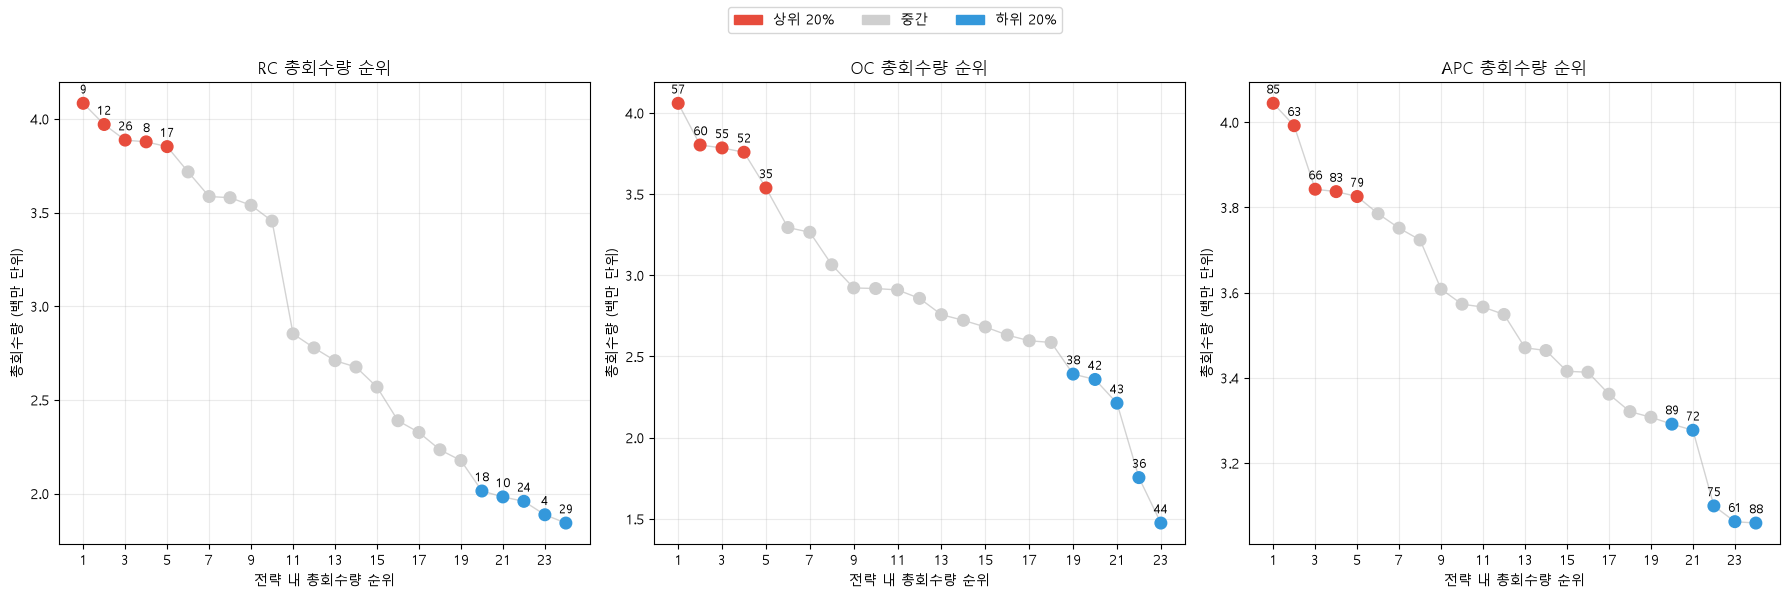

In [16]:
from matplotlib.patches import Patch

# 선정 구분별 색상
color_map = {
    '상위 20%': '#E74C3C',  # 빨간색
    '중간': '#CFCFCF',      # 회색
    '하위 20%': '#3498DB'   # 파란색
}

# RC·OC·APC 그래프를 각각 생성
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

for ax, strategy in zip(axes, target_strategies):

    # 해당 전략을 총회수량 순위대로 정렬
    plot_df = (
        ranking_df[
            ranking_df['Strategy'] == strategy
        ]
        .sort_values('총회수량_순위')
        .copy()
    )

    # 그래프에서 읽기 쉽게 백만 단위로 변환
    plot_df['총회수량_백만'] = (
        plot_df['총회수량'] / 1_000_000
    )

    # 순위에 따른 총회수량 흐름 표시
    ax.plot(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        color='lightgray',
        linewidth=1,
        zorder=1
    )

    # 상위·중간·하위 구분에 따라 점 색상 지정
    point_colors = plot_df['선정구분'].map(color_map)

    ax.scatter(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        c=point_colors,
        s=70,
        zorder=2
    )

    # 상위·하위 20% 배치에만 Batch_ID 표시
    selected_df = plot_df[
        plot_df['선정구분'] != '중간'
    ]

    for _, row in selected_df.iterrows():
        ax.annotate(
            str(int(row[batch_col])),
            (
                row['총회수량_순위'],
                row['총회수량_백만']
            ),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )

    ax.set_title(f'{strategy} 총회수량 순위')
    ax.set_xlabel('전략 내 총회수량 순위')
    ax.set_ylabel('총회수량 (백만 단위)')
    ax.set_xticks(
        range(1, len(plot_df) + 1, 2)
    )
    ax.grid(alpha=0.25)

# 공통 범례
legend_items = [
    Patch(color='#E74C3C', label='상위 20%'),
    Patch(color='#CFCFCF', label='중간'),
    Patch(color='#3498DB', label='하위 20%')
]

fig.legend(
    handles=legend_items,
    loc='upper center',
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 5. 결과 해석

- 총회수량 기준 상·하위 20% 배치가 전략별로 명확하게 표시됐다.
- RC는 상위 5개가 약 385만~408만에 모여 있고, 10위 이후부터 총회수량이 크게 떨어진다.
- OC는 57번이 가장 높으며, 60·55·52번이 비슷한 수준이다. 35번 이후부터 감소 폭이 커진다.
- APC는 다른 전략보다 전체 총회수량이 높고 배치 간 차이가 작다. APC 하위 20%도 약 306만~329만으로 RC·OC의 일부 중상위 배치보다 높다.

중요한 해석

전략별 성과 수준이 다르므로 전체 배치를 섞어서 상위 20%를 선정하면 APC에 후보가 집중될 수 있다. 따라서 RC·OC·APC 내부에서 각각 후보를 선정하는 현재 방식이 전략별 운전 특성을 반영하는 데 적절하다.

다만 상위 20%는 후보 수를 일관되게 정하기 위한 규칙이다. 특히 APC는 5위와 6위 차이가 크지 않아 총회수량만으로 자연스럽게 구분되는 경계라고 보기는 어렵다. 최종 골든배치를 정하려면 최종 농도와 농도 궤적도 함께 확인해야 한다.

# 6. 상위 20% 후보의 최종 농도 순위 확인

In [17]:
# 시간순으로 정렬한 Train 데이터에서
# 배치별 최종 농도와 최대 농도 계산
batch_kpi = (
    train_df
    .sort_values([batch_col, time_col])
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first'),

        # 각 배치의 마지막 시점 페니실린 농도
        최종농도=(p_col, 'last'),

        # 전체 운전기간 중 가장 높은 페니실린 농도
        최대농도=(p_col, 'max'),

        # 배치의 최종 운전시간
        운전시간=(time_col, 'max')
    )
)

# 전략 내부에서 최종 농도의 백분위 계산
# 값이 1에 가까울수록 해당 전략에서 최종 농도가 높음
batch_kpi['최종농도_백분위'] = (
    batch_kpi
    .groupby('Strategy')['최종농도']
    .rank(pct=True)
)

# 앞에서 계산한 총회수량 순위와 선정구분을 연결
batch_kpi = batch_kpi.merge(
    ranking_df[[
        batch_col,
        'Strategy',
        '총회수량_순위',
        '선정구분'
    ]],
    on=[batch_col, 'Strategy'],
    how='left'
)

# 총회수량 상위 20% 후보만 추출
top_candidates = (
    batch_kpi[
        batch_kpi['선정구분'] == '상위 20%'
    ]
    .copy()
)

# 최종 농도 수준에 따라 후보 유형 구분
top_candidates['후보유형'] = '최종농도 중간 수준'

# 총회수량과 최종 농도가 모두 상위 20%인 경우
top_candidates.loc[
    top_candidates['최종농도_백분위'] >= 0.80,
    '후보유형'
] = '총회수량·최종농도 모두 상위 20%'

# 최종 농도가 전략 내 하위 50%보다 낮은 경우
# 50%와 정확히 같은 배치는 경계값이므로 포함하지 않음
top_candidates.loc[
    top_candidates['최종농도_백분위'] < 0.50,
    '후보유형'
] = '총회수량 상위·최종농도 하위 50%'

# 전략과 총회수량 순위대로 정렬
top_candidates = top_candidates.sort_values(
    ['Strategy', '총회수량_순위']
)

display(
    top_candidates[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위',
        '최종농도',
        '최대농도',
        '최종농도_백분위',
        '후보유형'
    ]].round(3)
)

# 후보 유형별 배치번호 요약
print('\n후보 유형별 Batch_ID')

for candidate_type, group in top_candidates.groupby('후보유형'):
    print(
        candidate_type,
        ':',
        sorted(group[batch_col].tolist())
    )

,Strategy,Batch_ID,총회수량,총회수량_순위,최종농도,최대농도,최종농도_백분위,후보유형
65,APC,85,4044300.0,1.0,31.898,31.898,0.917,총회수량·최종농도 모두 상위 20%
49,APC,63,3991800.0,2.0,28.677,28.739,0.458,총회수량 상위·최종농도 하위 50%
52,APC,66,3842700.0,3.0,26.655,26.691,0.167,총회수량 상위·최종농도 하위 50%
64,APC,83,3837100.0,4.0,27.214,27.214,0.250,총회수량 상위·최종농도 하위 50%
61,APC,79,3825600.0,5.0,31.531,31.546,0.875,총회수량·최종농도 모두 상위 20%
43,OC,57,4059100.0,1.0,32.518,32.518,0.957,총회수량·최종농도 모두 상위 20%
46,OC,60,3802300.0,2.0,18.818,25.136,0.435,총회수량 상위·최종농도 하위 50%
41,OC,55,3784400.0,3.0,27.268,28.272,0.783,최종농도 중간 수준
39,OC,52,3757800.0,4.0,22.300,26.519,0.522,최종농도 중간 수준
25,OC,35,3537900.0,5.0,28.302,28.302,0.870,총회수량·최종농도 모두 상위 20%



후보 유형별 Batch_ID
총회수량 상위·최종농도 하위 50% : [9, 60, 63, 66, 83]
총회수량·최종농도 모두 상위 20% : [8, 35, 57, 79, 85]
최종농도 중간 수준 : [12, 17, 26, 52, 55]


### 6. 결과 해석

총회수량 상위 20% 후보 15개가 최종 농도에 따라 정확히 세 그룹으로 나뉘었다.

1. 두 지표가 모두 높은 후보
- RC: 8
- OC: 35, 57
- APC: 79, 85

총회수량과 최종 농도가 모두 전략 내 상위 20%이므로 현재 가장 강한 골든배치 후보다.

2. 총회수량은 높지만 최종 농도가 낮은 후보
- RC: 9
- OC: 60
- APC: 63, 66, 83

다만 이 다섯 배치를 같은 유형의 이상으로 해석하면 안 된다.

- 9·60번은 최대농도보다 최종농도가 크게 낮아 후반부 농도 하락이 의심된다.
- 63·66·83번은 최대농도와 최종농도가 거의 같아 후반부 하락은 없다. 다만 APC 안에서 농도 수준이 상대적으로 낮다.

즉, 9·60번은 후반부 성능 저하형, 63·66·83번은 상대적 저농도형에 가까울 가능성이 있다.

3. 최종 농도가 중간 수준인 후보
- RC: 12, 17, 26
- OC: 52, 55

12·26번은 최종 농도 백분위가 각각 0.792와 0.750으로 상위 20% 기준에 근접한다. 단순히 0.8 미만이라는 이유로 제외하면 안 된다.

또한 52번은 최대농도 26.519에서 최종농도 22.300으로 감소해 추가 확인이 필요하다.

최종 농도 백분위는 각 전략 안에서의 상대적인 순위다. 따라서 최종 농도 하위 50%라는 표현이 곧 절대적으로 낮은 농도나 공정 이상을 의미하지는 않는다.

# 1. P(t) 궤적 오버레이 — 이상후보 vs 대조군

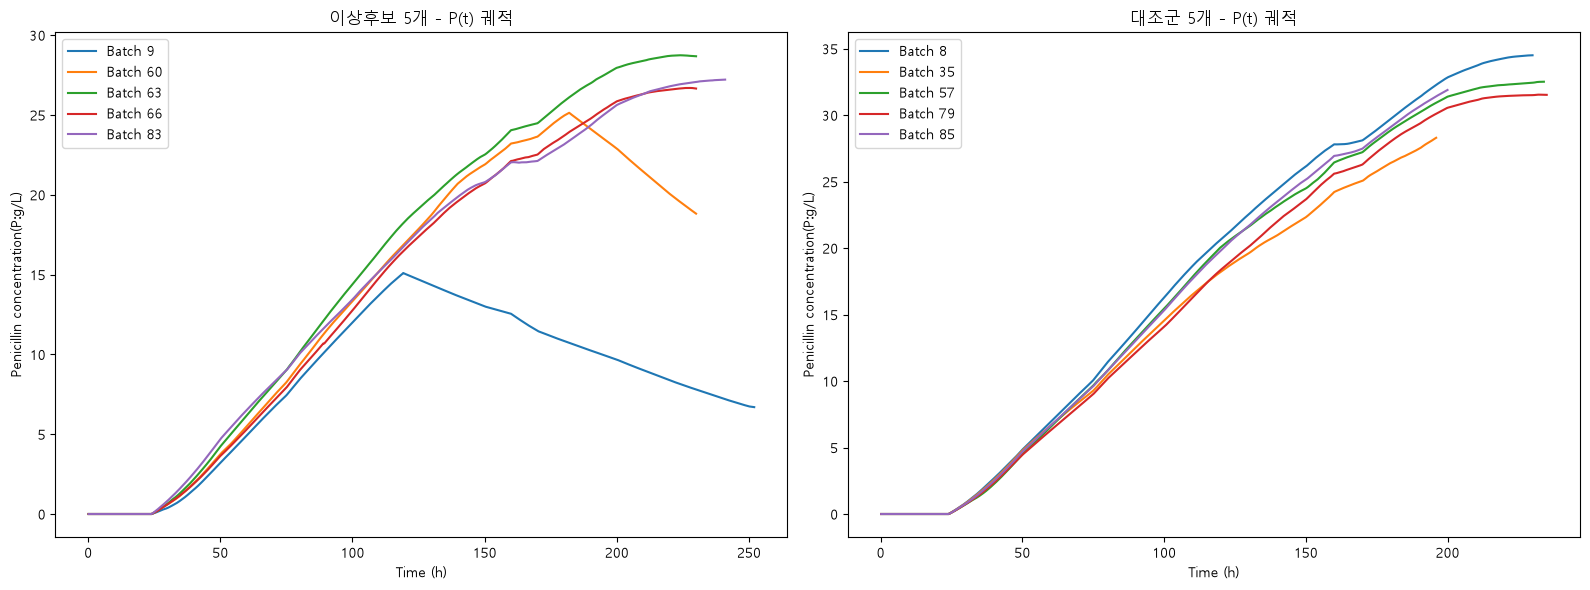

In [4]:
# 확정된 배치 목록
# - 이상후보: 총회수량은 상위20%인데 최종농도는 하위50%인 배치 (지표 불일치)
# - 대조군: 총회수량, 최종농도 둘 다 상위20%인 배치 (지표 일치, 정상 비교기준)
anomaly = [9, 60, 63, 66, 83]
control = [8, 35, 57, 79, 85]

# 그래프 두 개를 나란히 그릴 도화지 준비 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽 그래프: 이상후보 5개 배치의 시간에 따른 P(농도) 변화 ---
for b in anomaly:
    sub = df[df[batch_col]==b]  # 해당 배치번호 데이터만 추출
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}')  # 시간(x) vs 농도(y) 선그래프
axes[0].set_title('이상후보 5개 - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()  # 범례(어떤 색이 몇 번 배치인지) 표시

# --- 오른쪽 그래프: 대조군 5개 배치도 동일한 방식으로 ---
for b in control:
    sub = df[df[batch_col]==b]
    axes[1].plot(sub[time_col], sub[p_col], label=f'Batch {b}')
axes[1].set_title('대조군 5개 - P(t) 궤적')
axes[1].set_xlabel(time_col); axes[1].set_ylabel(p_col)
axes[1].legend()

plt.tight_layout()  # 그래프 간 간격 자동 조정(겹침 방지)
plt.show()

# 1. 총수율 컬럼의 계산 구조 및 단위 스케일 확인

## 1-2. 배치 단위 요약표 생성

- 총수율은 시간에 따라 변하는 센서값이 아니라 배치마다 하나씩 부여된 최종 결과값입니다.
- 총수율 ≈ 중간수확량 + 종료시수확량이 맞습니다.
- 최대 상대오차가 0.0042%에 불과하므로 차이는 반올림 수준입니다.
--> 따라서 엄밀히는 ‘기질 대비 수율’보다 총회수량 또는 총생산량에 가깝습니다.
- 단위는 의심스럽습니다. 종료시수확량이 단순 질량 계산보다 중앙값 기준 약 1,009배 큽니다. kg가 아니라 g 단위 값이 - - 잘못 표기됐을 가능성이 있지만, 현재 계산만으로 확정할 수는 없습니다.

단위가 잘못됐더라도 모든 배치에 동일한 스케일이 적용됐다면 순위에는 영향이 없으므로 골든 후보 선정은 가능합니다. 문서에는 일단 데이터셋 제공 총회수량이라고 쓰는 것이 안전합니다.

### 총회수량과 최종 농도는 서로 다른 성과지표!
- 총회수량–생산성: 순위상관 0.942
--\ 거의 같은 배치를 높게 평가
-- 생산성이 총회수량을 운전시간으로 나눈 파생지표라 어느 정도 당연한 결과
- 총회수량–최종 농도: 순위상관 0.390
-- 두 지표의 배치 순위가 상당히 다름
- 총회수량 상위 5개와 최종 농도 상위 5개의 공통 배치:
-- RC 1개
-- OC 2개
-- APC 2개

- 따라서 총회수량 기준 골든배치는 “최종 농도가 높은 배치”가 아니라 “총회수량이 높은 배치”입니다.